# Profilowanie pliku MCAP z urządzenia robotycznego

Celem notebooka jest analiza zawartości pliku MCAP pochodzącego z urządzenia robotycznego.  
W ramach profilowania sprawdzono dostępne tematy, liczbę wiadomości, typy danych, dane GPS, dane IMU oraz obecność obrazów multimedialnych.

In [89]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from mcap.reader import make_reader
from mcap_ros2.reader import read_ros2_messages

In [90]:
MCAP_PATH = Path("../data/raw/uav_drone_2025-12-10_150249_0.mcap")
PROCESSED_DIR = Path("../data/processed")

GPS_CSV_PATH = PROCESSED_DIR / "robot_positions.csv"
IMU_CSV_PATH = PROCESSED_DIR / "imu_raw.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Plik MCAP istnieje:", MCAP_PATH.exists())
print("Ścieżka:", MCAP_PATH)

Plik MCAP istnieje: True
Ścieżka: ..\data\raw\uav_drone_2025-12-10_150249_0.mcap


In [91]:
topics_counter = Counter()
topic_schemas = {}
topic_encodings = {}

with open(MCAP_PATH, "rb") as f:
    reader = make_reader(f)

    for schema, channel, message in reader.iter_messages(log_time_order=True):
        topics_counter[channel.topic] += 1

        if schema is not None:
            topic_schemas[channel.topic] = schema.name
            topic_encodings[channel.topic] = {
                "schema_encoding": schema.encoding,
                "message_encoding": channel.message_encoding,
            }
        else:
            topic_schemas[channel.topic] = "BRAK_SCHEMA"
            topic_encodings[channel.topic] = {
                "schema_encoding": None,
                "message_encoding": channel.message_encoding,
            }

topics_df = pd.DataFrame([
    {
        "topic": topic,
        "message_count": count,
        "schema": topic_schemas.get(topic),
        "schema_encoding": topic_encodings.get(topic, {}).get("schema_encoding"),
        "message_encoding": topic_encodings.get(topic, {}).get("message_encoding"),
    }
    for topic, count in topics_counter.most_common()
])

topics_df

,topic,message_count,schema,schema_encoding,message_encoding
0,/sensing/imu/imu_raw,197684,sensor_msgs/msg/Imu,ros2msg,cdr
1,/sensing/lidar/top/lidar_packets,158122,ouster_sensor_msgs/msg/PacketMsg,ros2idl,cdr
2,/sensing/lidar/top/imu_packets,49412,ouster_sensor_msgs/msg/PacketMsg,ros2idl,cdr
3,/sensing/gnss/ublox_rover_node/rxmrtcm,29640,ublox_msgs/msg/RxmRTCM,ros2msg,cdr
4,/sensing/gnss/ublox_moving_base_node/navrelposned,4940,ublox_msgs/msg/NavRELPOSNED9,ros2msg,cdr
5,/sensing/gnss/ublox_rover_node/fix,4937,sensor_msgs/msg/NavSatFix,ros2msg,cdr
6,/sensing/gnss/gnss_transforms/rover_pose_cov,4937,geometry_msgs/msg/PoseWithCovarianceStamped,ros2msg,cdr
7,/sensing/gnss/ublox_moving_base_node/fix,4937,sensor_msgs/msg/NavSatFix,ros2msg,cdr
8,/tf,4937,tf2_msgs/msg/TFMessage,ros2msg,cdr
9,/sensing/gnss/ublox_moving_base_node/fix_velocity,4936,geometry_msgs/msg/TwistWithCovarianceStamped,ros2msg,cdr


In [92]:
print("Liczba różnych tematów:", topics_df["topic"].nunique())
print("Łączna liczba wiadomości:", topics_df["message_count"].sum())

Liczba różnych tematów: 23
Łączna liczba wiadomości: 508111


## Podgląd przykładowych wiadomości z tematów MCAP

Przed wyodrębnieniem konkretnych danych sprawdzono przykładowe wiadomości z wybranych tematów.  
Pozwala to zweryfikować, jakie pola faktycznie występują w danych i które z nich nadają się do dalszej analizy statystycznej.

In [93]:
def preview_topic(topic_name, limit=3, max_chars=1200):

    try:
        counter = 0

        for msg in read_ros2_messages(str(MCAP_PATH), topics=[topic_name]):
            ros_msg = msg.ros_msg
            print(f"\nWiadomość nr {counter + 1}")
            print(f"Czas: {msg.log_time_ns / 1_000_000_000:.3f} s")

            summary(ros_msg, max_chars=max_chars)

            counter += 1
            if counter >= limit:
                break

        if counter == 0:
            print("Brak wiadomości w tym topicu.")

    except Exception as e:
        print("Nie udało się zdekodować tego topicu.")
        print("Powód:", type(e).__name__, "-", e)


def summary(msg, max_chars=1200):
    # Obrazy
    if all(hasattr(msg, attr) for attr in ["height", "width", "encoding", "data"]):
        print("Typ: obraz")
        print(f"height: {msg.height}, width: {msg.width}, encoding: {msg.encoding}, step: {msg.step}")
        print(f"Rozmiar pola data: {len(msg.data)} bajtów")

    # GPS / GNSS
    elif hasattr(msg, "latitude") and hasattr(msg, "longitude"):
        print("Typ: dane GNSS/GPS")
        print(f"latitude: {msg.latitude}, longitude: {msg.longitude}")
        if hasattr(msg, "altitude"):
            print(f"altitude: {msg.altitude}")
        if hasattr(msg, "header"):
            print(f"frame_id: {msg.header.frame_id}")

    # IMU
    elif all(hasattr(msg, attr) for attr in ["orientation", "angular_velocity", "linear_acceleration"]):
        print("Typ: dane IMU")
        print(f"orientation: {msg.orientation}")
        print(f"angular_velocity: {msg.angular_velocity}")
        print(f"linear_acceleration: {msg.linear_acceleration}")

    # Inne typy
    else:
        text = str(msg)
        print(text[:max_chars])
        if len(text) > max_chars:
            print("... [ucięto długi wynik]")

In [94]:
# Zakładamy, że topics_df istnieje i jest posortowane wg liczby wiadomości
topics_list = topics_df["topic"].tolist()

# Wyświetlamy listę topiców z numerami
print("Lista topiców:")
for i, topic in enumerate(topics_list, start=1):
    print(f"{i:2d}. {topic}")

# Funkcja do wybrania topicu po numerze
def show_topic_by_number(num, limit=3, max_chars=500):
    if 1 <= num <= len(topics_list):
        topic_name = topics_list[num - 1]
        print(f"\nWybrano topic nr {num}: {topic_name}")
        preview_topic(topic_name, limit=limit, max_chars=max_chars)
    else:
        print(f"Niepoprawny numer. Wybierz numer od 1 do {len(topics_list)}")

Lista topiców:
 1. /sensing/imu/imu_raw
 2. /sensing/lidar/top/lidar_packets
 3. /sensing/lidar/top/imu_packets
 4. /sensing/gnss/ublox_rover_node/rxmrtcm
 5. /sensing/gnss/ublox_moving_base_node/navrelposned
 6. /sensing/gnss/ublox_rover_node/fix
 7. /sensing/gnss/gnss_transforms/rover_pose_cov
 8. /sensing/gnss/ublox_moving_base_node/fix
 9. /tf
10. /sensing/gnss/ublox_moving_base_node/fix_velocity
11. /sensing/gnss/gnss_transforms/rear_axis_pose
12. /sensing/gnss/gnss_transforms/moving_base_pose
13. /sensing/gnss/gnss_transforms/moving_base_pose_cov
14. /sensing/gnss/gnss_transforms/rear_axis_pose_cov
15. /sensing/gnss/ublox_rover_node/fix_velocity
16. /sensing/gnss/ublox_rover_node/navrelposned
17. /sensing/gnss/gnss_transforms/rover_pose
18. /sensing/gnss/rtcm
19. /sensing/gnss/ublox_moving_base_node/rxmrtcm
20. /diagnostics
21. /sensing/omni/omni_camera/image_raw
22. /sensing/camera/front/image_raw
23. /tf_static


In [95]:
# Wybierz numer topicu do podglądu
show_topic_by_number(7)


Wybrano topic nr 7: /sensing/gnss/gnss_transforms/rover_pose_cov

Wiadomość nr 1
Czas: 1765375369.785 s
PoseWithCovarianceStamped(header=Header(stamp=Time(sec=1765375369, nanosec=784145112), frame_id=map), pose=PoseWithCovariance(pose=Pose(position=Point(x=32748.558282974176, y=7484.849881257862, z=100.0), orientation=Quaternion(x=0.0, y=0.0, z=0.7338178483296117, w=0.6793462780297681)), covariance=[0.00019600000000000002, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00019600000000000002, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1000.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1000.0, 0.0, 0.0,
... [ucięto długi wynik]

Wiadomość nr 2
Czas: 1765375369.888 s
PoseWithCovarianceStamped(header=Header(stamp=Time(sec=1765375369, nanosec=887929830), frame_id=map), pose=PoseWithCovariance(pose=Pose(position=Point(x=32748.558282974176, y=7484.849881257862, z=99.999), orientation=Quaternion(x=0.0, y=0.0, z=0.7333445829443337, w=0.6798571340114049)), covariance=[0.00019600000000000002, 0.0, 0

## Wybór danych do dalszej analizy

Na podstawie podglądu przykładowych wiadomości wybrano temat `/sensing/gnss/ublox_rover_node/fix` jako źródło danych pozycyjnych robota. Wiadomości z tego tematu zawierają pola `latitude` oraz `longitude`, dlatego można je przekształcić do formatu wymaganego w projekcie: `Id, timestamp, latitude, longitude`.

Dodatkowo do analizy statystycznej wybrano temat `/sensing/imu/imu_raw`, który zawiera dane z jednostki IMU: orientację, prędkość kątową oraz przyspieszenie liniowe.

W pliku wykryto również dane obrazowe z kamer oraz dane LiDAR. Dane LiDAR są zapisane jako pakiety `ouster_sensor_msgs/msg/PacketMsg`, dlatego w ramach profilowania uwzględniono ich obecność, liczbę wiadomości oraz typ danych, bez szczegółowej dekodacji pomiarów.

## Analiza danych GNSS/GPS

Na podstawie wcześniejszego podglądu tematów MCAP wybrano temat `/sensing/gnss/ublox_rover_node/fix` jako główne źródło danych pozycyjnych urządzenia robotycznego.

Wiadomości w tym temacie mają typ `sensor_msgs/msg/NavSatFix` i zawierają między innymi szerokość geograficzną (`latitude`), długość geograficzną (`longitude`) oraz wysokość (`altitude`). Na potrzeby projektu wyodrębniono dane w formacie zgodnym z wymaganiami:

`Id, timestamp, latitude, longitude`

Ponieważ analizowany plik MCAP pochodzi z jednego urządzenia, a wiadomości GNSS nie zawierają osobnego pola identyfikatora robota, wszystkim rekordom przypisano `Id = 1`.

W dalszej części przeprowadzono podstawowe profilowanie danych GPS: sprawdzono liczbę rekordów, pierwsze i ostatnie wiersze, typy danych, brakujące wartości, statystyki opisowe, zakres czasowy pomiarów, częstotliwość próbkowania oraz rozkład i trasę ruchu urządzenia.

In [96]:
GPS_TOPIC = "/sensing/gnss/ublox_rover_node/fix"
ROBOT_ID = 1

gps_rows = []

for msg in read_ros2_messages(str(MCAP_PATH), topics=[GPS_TOPIC]):
    ros_msg = msg.ros_msg

    gps_rows.append({
        "Id": ROBOT_ID,
        "timestamp": msg.log_time_ns / 1_000_000_000,
        "latitude": ros_msg.latitude,
        "longitude": ros_msg.longitude,
    })

gps_df = pd.DataFrame(gps_rows)
gps_df.to_csv(GPS_CSV_PATH, index=False)

print("Zapisano:", GPS_CSV_PATH)
print("Liczba rekordów GPS:", len(gps_df))

Zapisano: ..\data\processed\robot_positions.csv
Liczba rekordów GPS: 4937


In [97]:
gps_df.head()

,Id,timestamp,latitude,longitude
0,1,1.765375e+09,52.401481,16.951285
1,1,1.765375e+09,52.401481,16.951285
2,1,1.765375e+09,52.401481,16.951285
3,1,1.765375e+09,52.401481,16.951285
4,1,1.765375e+09,52.401481,16.951285


In [98]:
gps_df.tail()

,Id,timestamp,latitude,longitude
4932,1,1.765376e+09,52.40138,16.951138
4933,1,1.765376e+09,52.40138,16.951138
4934,1,1.765376e+09,52.40138,16.951138
4935,1,1.765376e+09,52.40138,16.951138
4936,1,1.765376e+09,52.40138,16.951138


In [99]:
gps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4937 entries, 0 to 4936
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         4937 non-null   int64  
 1   timestamp  4937 non-null   float64
 2   latitude   4937 non-null   float64
 3   longitude  4937 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 154.4 KB


In [100]:
gps_df.isnull().sum()

Id           0
timestamp    0
latitude     0
longitude    0
dtype: int64

In [101]:
df = gps_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
df[["timestamp", "latitude", "longitude"]].describe()

,latitude,longitude
count,4937.000000,4937.000000
mean,52.401521,16.951635
std,0.000187,0.000428
min,52.401220,16.951101
25%,52.401380,16.951276
50%,52.401466,16.951514
75%,52.401624,16.952009
max,52.401965,16.952410


In [102]:
gps_df[["timestamp", "latitude", "longitude"]].describe()

,timestamp,latitude,longitude
count,4.937000e+03,4937.000000,4937.000000
mean,1.765376e+09,52.401521,16.951635
std,1.426735e+02,0.000187,0.000428
min,1.765375e+09,52.401220,16.951101
25%,1.765375e+09,52.401380,16.951276
50%,1.765376e+09,52.401466,16.951514
75%,1.765376e+09,52.401624,16.952009
max,1.765376e+09,52.401965,16.952410


In [103]:
gps_df = gps_df.sort_values("timestamp")
gps_df["time_diff"] = gps_df["timestamp"].diff()

gps_df["time_diff"].describe()

count    4936.000000
mean        0.100103
std         0.005942
min         0.060780
25%         0.097347
50%         0.100008
75%         0.102575
max         0.184216
Name: time_diff, dtype: float64

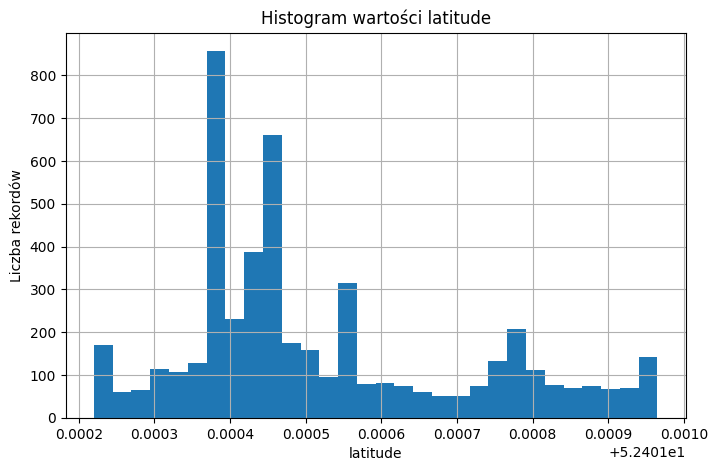

In [104]:
plt.figure(figsize=(8, 5))
gps_df["latitude"].hist(bins=30)
plt.title("Histogram wartości latitude")
plt.xlabel("latitude")
plt.ylabel("Liczba rekordów")
plt.show()

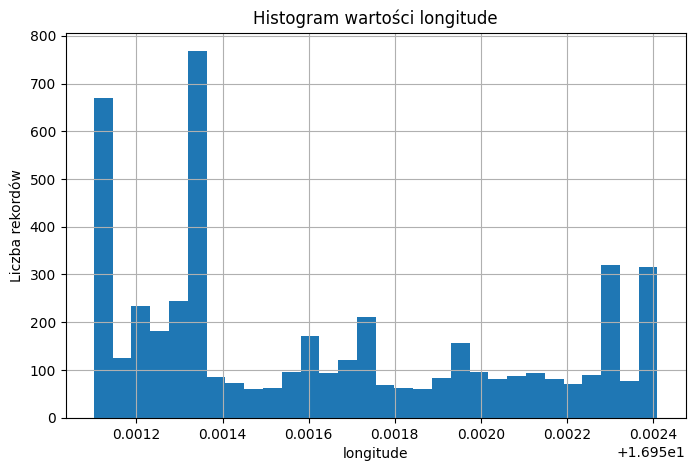

In [105]:
plt.figure(figsize=(8, 5))
gps_df["longitude"].hist(bins=30)
plt.title("Histogram wartości longitude")
plt.xlabel("longitude")
plt.ylabel("Liczba rekordów")
plt.show()

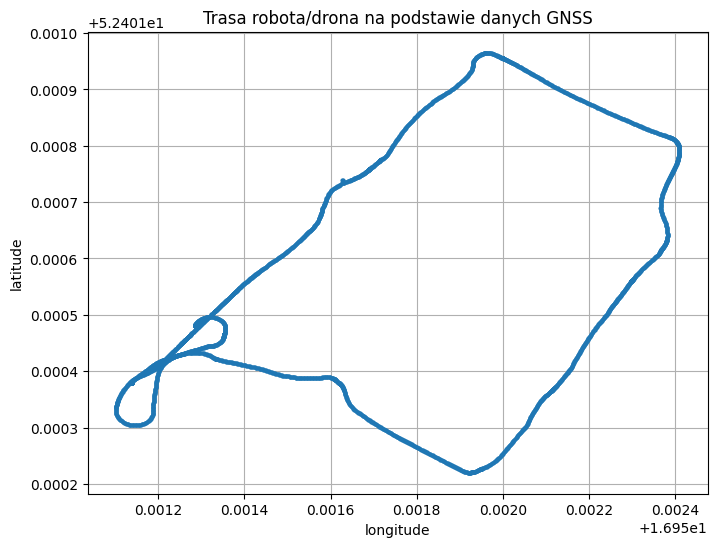

In [106]:
plt.figure(figsize=(8, 6))
plt.plot(
    gps_df["longitude"],
    gps_df["latitude"],
    marker="o",
    markersize=2,
    linewidth=1
)

plt.title("Trasa robota/drona na podstawie danych GNSS")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.grid(True)
plt.show()

### Podsumowanie danych GPS

Dane GPS opisują zmiany położenia urządzenia w czasie. Każdy rekord zawiera identyfikator urządzenia, znacznik czasu oraz współrzędne geograficzne. Na podstawie tych danych możliwe jest odtworzenie trasy ruchu robota/drona oraz wykorzystanie ich w dalszych etapach projektu, między innymi do analizy geofencingu, bliskości względem czujników oraz potencjalnych kolizji.

Dane GPS stanowią główny zbiór pozycyjny wykorzystywany w dalszej części projektu.

## Analiza danych IMU

W pliku MCAP wykryto temat `/sensing/imu/imu_raw`, który zawiera dane z jednostki IMU, czyli Inertial Measurement Unit.

Dane IMU opisują ruch urządzenia robotycznego. W przykładowej wiadomości znajdują się trzy główne grupy wartości:

- `orientation` — orientacja urządzenia w przestrzeni,
- `angular_velocity` — prędkość kątowa wokół osi X, Y i Z,
- `linear_acceleration` — przyspieszenie liniowe w osiach X, Y i Z.

In [107]:
IMU_TOPIC = "/sensing/imu/imu_raw"

imu_rows = []

for msg in read_ros2_messages(str(MCAP_PATH), topics=[IMU_TOPIC]):
    imu_msg = msg.ros_msg

    timestamp = imu_msg.header.stamp.sec + imu_msg.header.stamp.nanosec / 1_000_000_000

    imu_rows.append({
        "timestamp": timestamp,

        "orientation_x": imu_msg.orientation.x,
        "orientation_y": imu_msg.orientation.y,
        "orientation_z": imu_msg.orientation.z,
        "orientation_w": imu_msg.orientation.w,

        "angular_velocity_x": imu_msg.angular_velocity.x,
        "angular_velocity_y": imu_msg.angular_velocity.y,
        "angular_velocity_z": imu_msg.angular_velocity.z,

        "linear_acceleration_x": imu_msg.linear_acceleration.x,
        "linear_acceleration_y": imu_msg.linear_acceleration.y,
        "linear_acceleration_z": imu_msg.linear_acceleration.z,
    })

imu_df = pd.DataFrame(imu_rows)
imu_df.to_csv(IMU_CSV_PATH, index=False)

print("Zapisano:", IMU_CSV_PATH)
print("Liczba rekordów IMU:", len(imu_df))

Zapisano: ..\data\processed\imu_raw.csv
Liczba rekordów IMU: 197684


In [108]:
imu_df.head()

,timestamp,orientation_x,orientation_y,orientation_z,orientation_w,angular_velocity_x,angular_velocity_y,angular_velocity_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z
0,1.765375e+09,-0.008000,0.004754,0.053381,-0.998531,-0.007895,0.009486,0.002001,0.096829,0.190470,9.781070
1,1.765375e+09,-0.008010,0.004756,0.053385,-0.998531,0.008325,-0.001320,-0.003472,0.090218,0.186725,9.775610
2,1.765375e+09,-0.008010,0.004771,0.053252,-0.998538,0.008036,0.001840,-0.001228,0.079705,0.197399,9.800425
3,1.765375e+09,-0.008023,0.004772,0.053264,-0.998537,0.010209,-0.000161,-0.009966,0.097644,0.189111,9.863426
4,1.765375e+09,-0.008031,0.004762,0.053275,-0.998536,0.006004,0.008389,-0.008918,0.065545,0.186051,9.870498


In [109]:
imu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197684 entries, 0 to 197683
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   timestamp              197684 non-null  float64
 1   orientation_x          197684 non-null  float64
 2   orientation_y          197684 non-null  float64
 3   orientation_z          197684 non-null  float64
 4   orientation_w          197684 non-null  float64
 5   angular_velocity_x     197684 non-null  float64
 6   angular_velocity_y     197684 non-null  float64
 7   angular_velocity_z     197684 non-null  float64
 8   linear_acceleration_x  197684 non-null  float64
 9   linear_acceleration_y  197684 non-null  float64
 10  linear_acceleration_z  197684 non-null  float64
dtypes: float64(11)
memory usage: 16.6 MB


In [110]:
imu_df.isnull().sum()

timestamp                0
orientation_x            0
orientation_y            0
orientation_z            0
orientation_w            0
angular_velocity_x       0
angular_velocity_y       0
angular_velocity_z       0
linear_acceleration_x    0
linear_acceleration_y    0
linear_acceleration_z    0
dtype: int64

In [111]:
imu_df.describe()

,timestamp,orientation_x,orientation_y,orientation_z,orientation_w,angular_velocity_x,angular_velocity_y,angular_velocity_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z
count,1.976840e+05,197684.000000,197684.000000,197684.000000,197684.000000,197684.000000,197684.000000,197684.000000,197684.000000,197684.000000,197684.000000
mean,1.765376e+09,-0.000104,0.003809,0.052865,-0.509385,0.000762,0.000647,0.002581,0.083392,0.082633,9.818328
std,1.426640e+02,0.007691,0.006118,0.753791,0.411611,0.017574,0.015981,0.107453,0.377212,0.350006,0.559750
min,1.765375e+09,-0.021514,-0.015100,-0.958367,-0.999978,-0.248925,-0.235392,-0.462169,-5.263843,-2.999095,4.852071
25%,1.765375e+09,-0.004128,-0.000538,-0.836222,-0.897464,-0.007495,-0.007766,-0.013425,-0.087179,-0.065299,9.682946
50%,1.765376e+09,-0.001731,0.003349,0.315166,-0.545876,0.000730,0.000757,-0.001158,0.066981,0.075635,9.817718
75%,1.765376e+09,0.004909,0.007449,0.829267,-0.394199,0.008960,0.009273,0.012723,0.222599,0.249863,9.949681
max,1.765376e+09,0.028279,0.018008,0.999980,0.647980,0.200100,0.145277,0.491315,2.985891,4.848635,16.360432


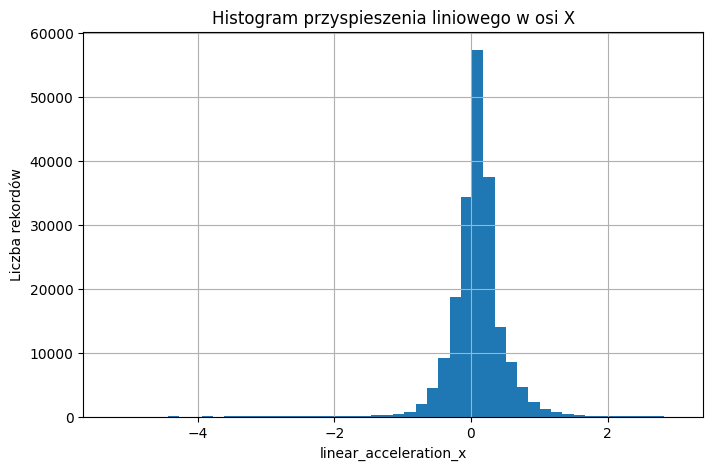

In [112]:
plt.figure(figsize=(8, 5))
imu_df["linear_acceleration_x"].hist(bins=50)

plt.title("Histogram przyspieszenia liniowego w osi X")
plt.xlabel("linear_acceleration_x")
plt.ylabel("Liczba rekordów")
plt.grid(True)
plt.show()

### Podsumowanie danych IMU

Dane IMU zawierają wartości liczbowe opisujące dynamikę ruchu urządzenia. W ramach profilowania sprawdzono podstawowe informacje o zbiorze, brakujące wartości oraz statystyki opisowe dla prędkości kątowej i przyspieszenia liniowego. Dane te stanowią uzupełnienie danych pozycyjnych GNSS.

## Dane multimedialne

W pliku MCAP wykryto dane obrazowe z kamer. Tematy `/sensing/omni/omni_camera/image_raw` oraz `/sensing/camera/front/image_raw` zawierają wiadomości typu `sensor_msgs/msg/Image`. W ramach profilowania wyświetlono przykładowy obraz z kamery przedniej.

W tym topicu jest 494 obrazków.
height: 600
width: 960
encoding: bgr8
step: 2880


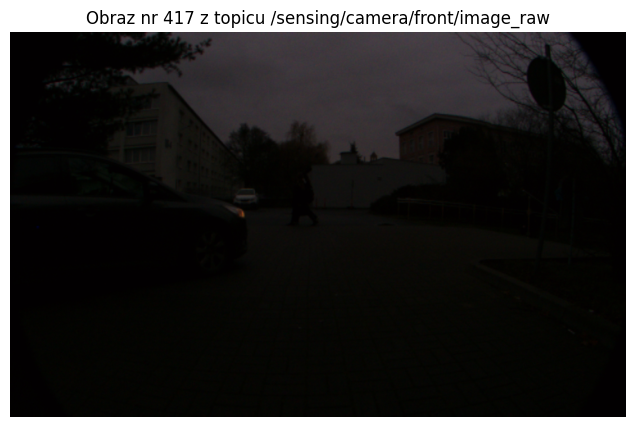

In [113]:
import numpy as np
import matplotlib.pyplot as plt

IMAGE_TOPIC = "/sensing/camera/front/image_raw"

image_messages = list(read_ros2_messages(str(MCAP_PATH), topics=[IMAGE_TOPIC]))
num_images = len(image_messages)
print(f"W tym topicu jest {num_images} obrazków.")

image_number = 417  # zmień na dowolny od 1 do num_images

if 1 <= image_number <= num_images:
    image_msg = image_messages[image_number - 1].ros_msg

    print("height:", image_msg.height)
    print("width:", image_msg.width)
    print("encoding:", image_msg.encoding)
    print("step:", image_msg.step)

    image_array = np.frombuffer(image_msg.data, dtype=np.uint8)
    image_array = image_array.reshape((image_msg.height, image_msg.width, 3))

    image_rgb = image_array[:, :, ::-1]

    plt.figure(figsize=(8, 5))
    plt.imshow(image_rgb)
    plt.title(f"Obraz nr {image_number} z topicu {IMAGE_TOPIC}")
    plt.axis("off")
    plt.show()
else:
    print(f"Niepoprawny numer. Wybierz od 1 do {num_images}.")